# EDA — Medical Abstracts TC Corpus

**Projeto:** Medical Triage MLOps

Este notebook realiza uma análise exploratória objetiva do dataset antes da modelagem.

### Objetivos
- entender a estrutura dos dados;
- verificar qualidade básica;
- analisar distribuição das classes;
- observar o tamanho dos textos;
- identificar repetições relevantes;
- visualizar palavras e bigramas frequentes;
- registrar conclusões para a próxima etapa.

> Este projeto é acadêmico e não deve ser utilizado para decisões clínicas.

## 1. Bibliotecas e configurações

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.feature_extraction.text import CountVectorizer

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

plt.rcParams.update({
    'figure.figsize': (11, 6),
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

CLASS_COLORS = ['#5B5FDE', '#16A085', '#F4B942', '#2980B9', '#E67E22']
SPLIT_COLORS = ['#5B5FDE', '#16A085']

print('Bibliotecas carregadas.')

Bibliotecas carregadas.


## 2. Carregamento dos dados

Estrutura esperada:

```text
data/raw/
├── medical_tc_train.csv
├── medical_tc_test.csv
└── medical_tc_labels.csv
```

In [2]:
def locate_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, current.parent, current.parent.parent]:
        expected = candidate / 'data' / 'raw' / 'medical_tc_train.csv'
        if expected.exists():
            return candidate
    raise FileNotFoundError('Não encontrei data/raw/medical_tc_train.csv.')

PROJECT_ROOT = locate_project_root()
DATA_DIR = PROJECT_ROOT / 'data' / 'raw'

train = pd.read_csv(DATA_DIR / 'medical_tc_train.csv')
test = pd.read_csv(DATA_DIR / 'medical_tc_test.csv')
labels = pd.read_csv(DATA_DIR / 'medical_tc_labels.csv')

label_map = dict(zip(labels['condition_label'], labels['condition_name']))
train['condition_name'] = train['condition_label'].map(label_map)
test['condition_name'] = test['condition_label'].map(label_map)

print(f'Treino: {train.shape}')
print(f'Teste:  {test.shape}')
print(f'Classes: {len(labels)}')

Treino: (11550, 3)
Teste:  (2888, 3)
Classes: 5


In [3]:
display(Markdown('#### Treino'))
display(train.head())
display(Markdown('#### Teste'))
display(test.head())
display(Markdown('#### Classes'))
display(labels)

#### Treino

,condition_label,medical_abstract,condition_name
0,5,Tissue changes around loose prostheses. A canine model to investigate the effects of an antiinflammatory agent. The ...,general pathological conditions
1,1,Neuropeptide Y and neuron-specific enolase levels in benign and malignant pheochromocytomas. Neuron-specific enolase...,neoplasms
2,2,"Sexually transmitted diseases of the colon, rectum, and anus. The challenge of the nineties. During the past two dec...",digestive system diseases
3,1,Lipolytic factors associated with murine and human cancer cachexia. We have identified a lipolytic factor in extract...,neoplasms
4,3,"Does carotid restenosis predict an increased risk of late symptoms, stroke, or death? The identification of carotid ...",nervous system diseases


#### Teste

,condition_label,medical_abstract,condition_name
0,3,Obstructive sleep apnea following topical oropharyngeal anesthesia in loud snorers. Previous studies support the pre...,nervous system diseases
1,5,"Neutrophil function and pyogenic infections in bone marrow transplant recipients. In a consecutive entry trial, the ...",general pathological conditions
2,5,A phase II study of combined methotrexate and teniposide infusions prior to reinduction therapy in relapsed childhoo...,general pathological conditions
3,1,Flow cytometric DNA analysis of parathyroid tumors. Implication of aneuploidy for pathologic and biologic classifica...,neoplasms
4,4,Paraneoplastic vasculitic neuropathy: a treatable neuropathy. Paraneoplastic vasculitic neuropathy has been recently...,cardiovascular diseases


#### Classes

,condition_label,condition_name
0,1,neoplasms
1,2,digestive system diseases
2,3,nervous system diseases
3,4,cardiovascular diseases
4,5,general pathological conditions


## 3. Estrutura e qualidade básica

Verificamos os pontos essenciais: valores ausentes, textos vazios, quantidade de textos únicos e duplicatas exatas.

In [4]:
summary = pd.DataFrame({
    'Conjunto': ['Treino', 'Teste'],
    'Linhas': [len(train), len(test)],
    'Textos únicos': [train['medical_abstract'].nunique(), test['medical_abstract'].nunique()],
    'Valores nulos': [int(train.isna().sum().sum()), int(test.isna().sum().sum())],
    'Textos vazios': [
        int(train['medical_abstract'].fillna('').str.strip().eq('').sum()),
        int(test['medical_abstract'].fillna('').str.strip().eq('').sum()),
    ],
    'Duplicatas exatas': [int(train.duplicated().sum()), int(test.duplicated().sum())],
})
display(summary)

,Conjunto,Linhas,Textos únicos,Valores nulos,Textos vazios,Duplicatas exatas
0,Treino,11550,9445,0,0,0
1,Teste,2888,2770,0,0,0


In [5]:
display(pd.DataFrame({
    'Coluna': train.columns,
    'Tipo no treino': train.dtypes.astype(str).values,
}))

,Coluna,Tipo no treino
0,condition_label,int64
1,medical_abstract,object
2,condition_name,object


### Resultado

O dataset possui uma estrutura simples, formada principalmente pelo texto do resumo médico e pelo código da classe. A análise básica indica se existe algum problema de qualidade que precisa ser tratado antes da modelagem.

## 4. Distribuição das classes

In [6]:
class_distribution = (
    train.groupby(['condition_label', 'condition_name'])
    .size()
    .rename('quantidade')
    .reset_index()
    .sort_values('condition_label')
)
class_distribution['percentual'] = class_distribution['quantidade'] / class_distribution['quantidade'].sum()
display(class_distribution)

,condition_label,condition_name,quantidade,percentual
0,1,neoplasms,2530,0.22
1,2,digestive system diseases,1195,0.10
2,3,nervous system diseases,1540,0.13
3,4,cardiovascular diseases,2441,0.21
4,5,general pathological conditions,3844,0.33


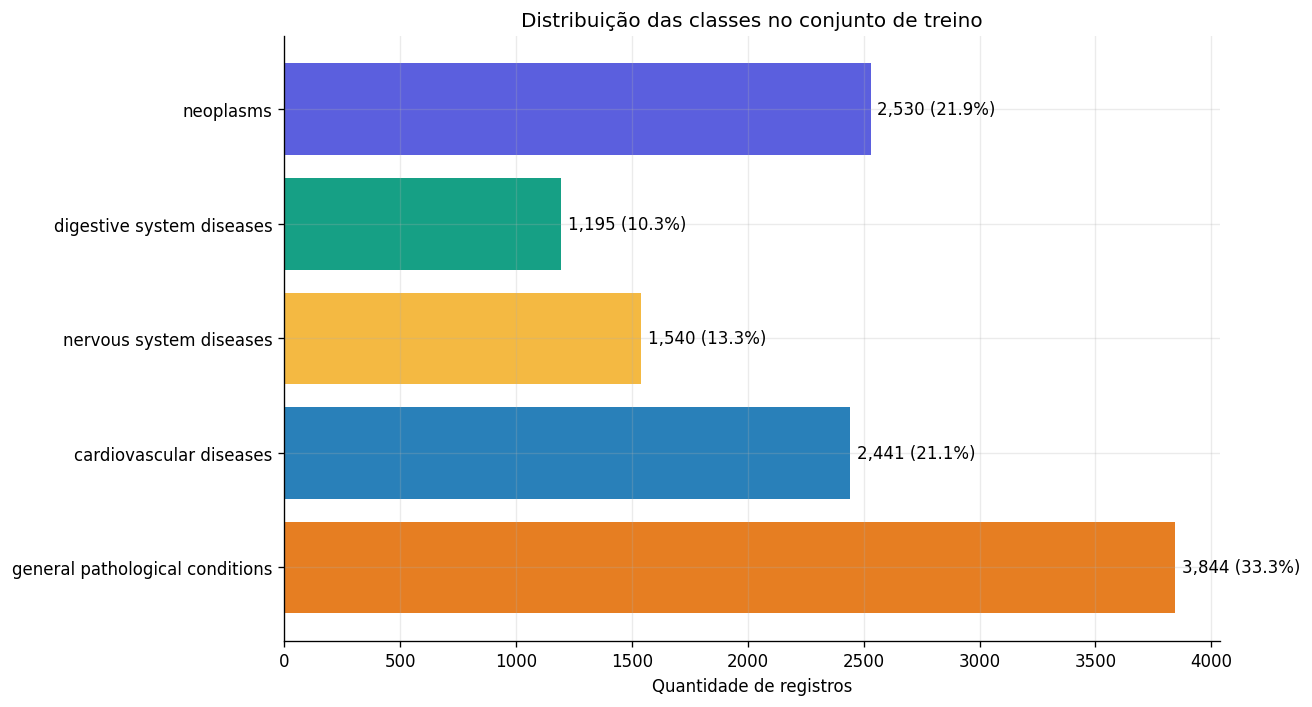

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(class_distribution['condition_name'], class_distribution['quantidade'], color=CLASS_COLORS)
ax.bar_label(
    bars,
    labels=[f'{count:,} ({pct:.1%})' for count, pct in zip(class_distribution['quantidade'], class_distribution['percentual'])],
    padding=4,
)
ax.set_title('Distribuição das classes no conjunto de treino')
ax.set_xlabel('Quantidade de registros')
ax.set_ylabel('')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Comparação entre treino e teste

In [8]:
def proportional_distribution(df, name):
    result = df['condition_name'].value_counts(normalize=True).rename('percentual').reset_index()
    result.columns = ['condition_name', 'percentual']
    result['conjunto'] = name
    return result

comparison = (
    pd.concat([
        proportional_distribution(train, 'Treino'),
        proportional_distribution(test, 'Teste'),
    ])
    .pivot(index='condition_name', columns='conjunto', values='percentual')
    .reindex(labels['condition_name'])
)
display(comparison)

conjunto,Teste,Treino
condition_name,,
neoplasms,0.22,0.22
digestive system diseases,0.10,0.10
nervous system diseases,0.13,0.13
cardiovascular diseases,0.21,0.21
general pathological conditions,0.33,0.33


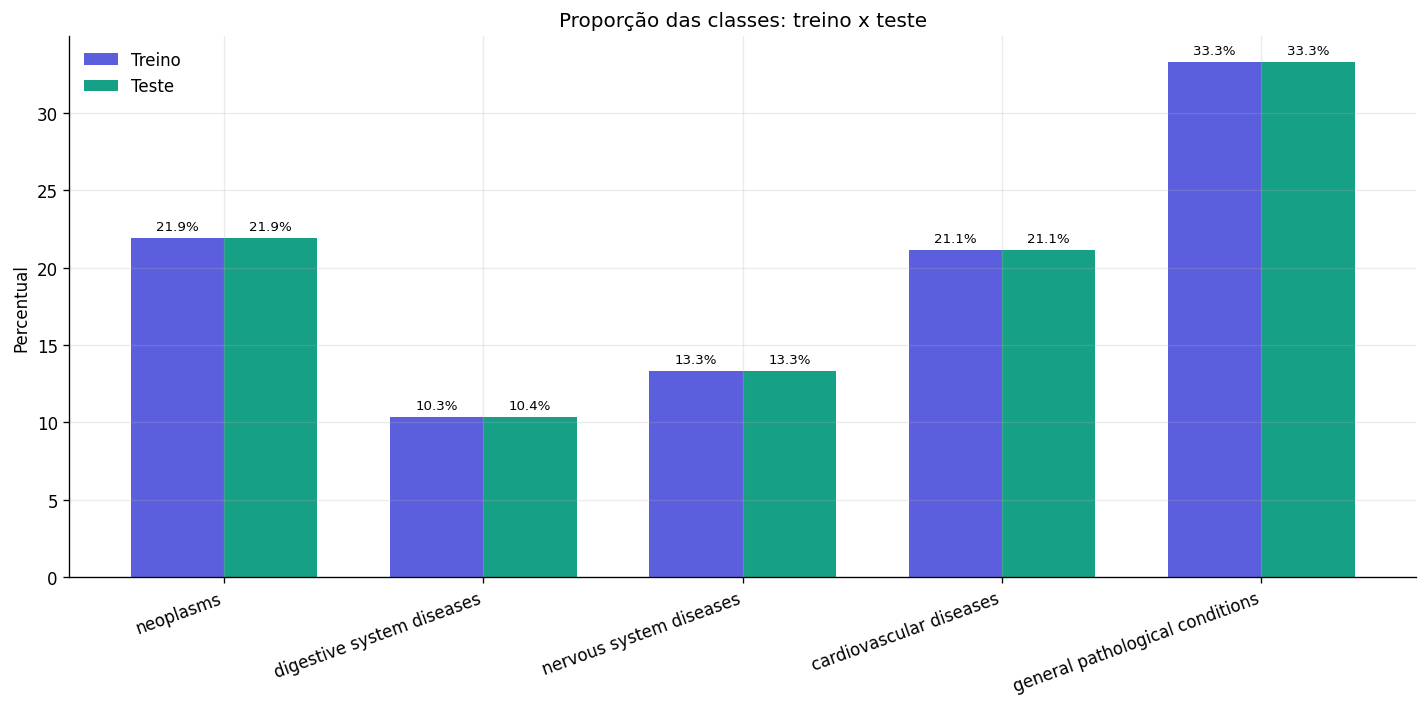

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison.index))
width = 0.36
bars_train = ax.bar(x - width/2, comparison['Treino'] * 100, width, label='Treino', color=SPLIT_COLORS[0])
bars_test = ax.bar(x + width/2, comparison['Teste'] * 100, width, label='Teste', color=SPLIT_COLORS[1])
ax.bar_label(bars_train, fmt='%.1f%%', padding=3, fontsize=8)
ax.bar_label(bars_test, fmt='%.1f%%', padding=3, fontsize=8)
ax.set_title('Proporção das classes: treino x teste')
ax.set_ylabel('Percentual')
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=20, ha='right')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [10]:
counts = train['condition_name'].value_counts()
imbalance_ratio = counts.max() / counts.min()
print(f'Maior classe: {counts.idxmax()} ({counts.max():,} registros)')
print(f'Menor classe: {counts.idxmin()} ({counts.min():,} registros)')
print(f'Razão maior/menor classe: {imbalance_ratio:.2f}x')

Maior classe: general pathological conditions (3,844 registros)
Menor classe: digestive system diseases (1,195 registros)
Razão maior/menor classe: 3.22x


### Interpretação

Existe **desbalanceamento moderado** entre as classes. Por isso, além da acurácia, será importante acompanhar **macro F1-score**, **recall por classe** e **matriz de confusão**.

## 5. Tamanho dos textos

In [11]:
def add_text_length_features(df):
    result = df.copy()
    text = result['medical_abstract'].fillna('').astype(str)
    result['n_chars'] = text.str.len()
    result['n_words'] = text.str.findall(r'\b\w+\b').str.len()
    return result

train_eda = add_text_length_features(train)
display(train_eda[['n_chars', 'n_words']].describe(percentiles=[0.05, 0.50, 0.95, 0.99]).T)

,count,mean,std,min,5%,50%,95%,99%,max
n_chars,"11,550.00","1,229.10",505.96,170.00,441.00,"1,208.00","2,049.00","2,570.00","3,999.00"
n_words,"11,550.00",185.55,79.75,26.00,63.00,181.00,315.00,396.51,622.00


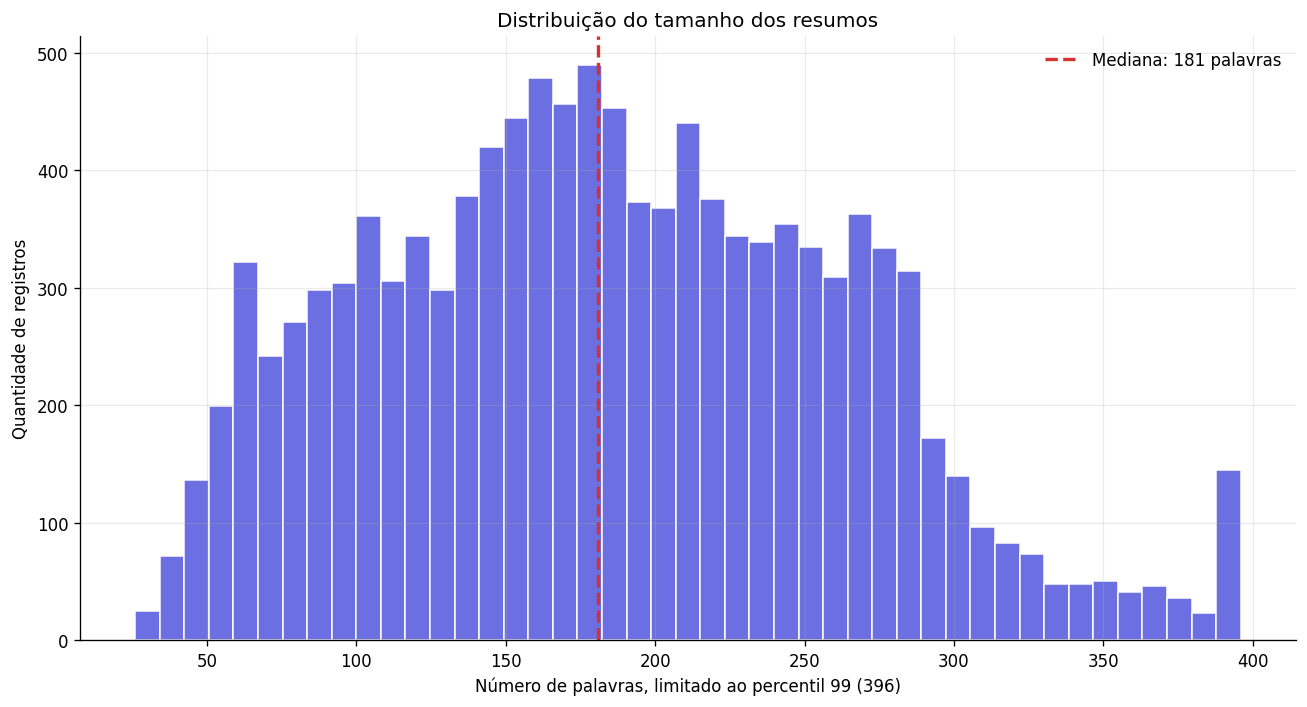

In [12]:
limit = int(train_eda['n_words'].quantile(0.99))
fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(train_eda['n_words'].clip(upper=limit), bins=45, color='#5B5FDE', edgecolor='white', alpha=0.9)
median_words = train_eda['n_words'].median()
ax.axvline(median_words, color='#D63031', linestyle='--', linewidth=2, label=f'Mediana: {median_words:.0f} palavras')
ax.set_title('Distribuição do tamanho dos resumos')
ax.set_xlabel(f'Número de palavras, limitado ao percentil 99 ({limit})')
ax.set_ylabel('Quantidade de registros')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Tamanho dos textos por classe

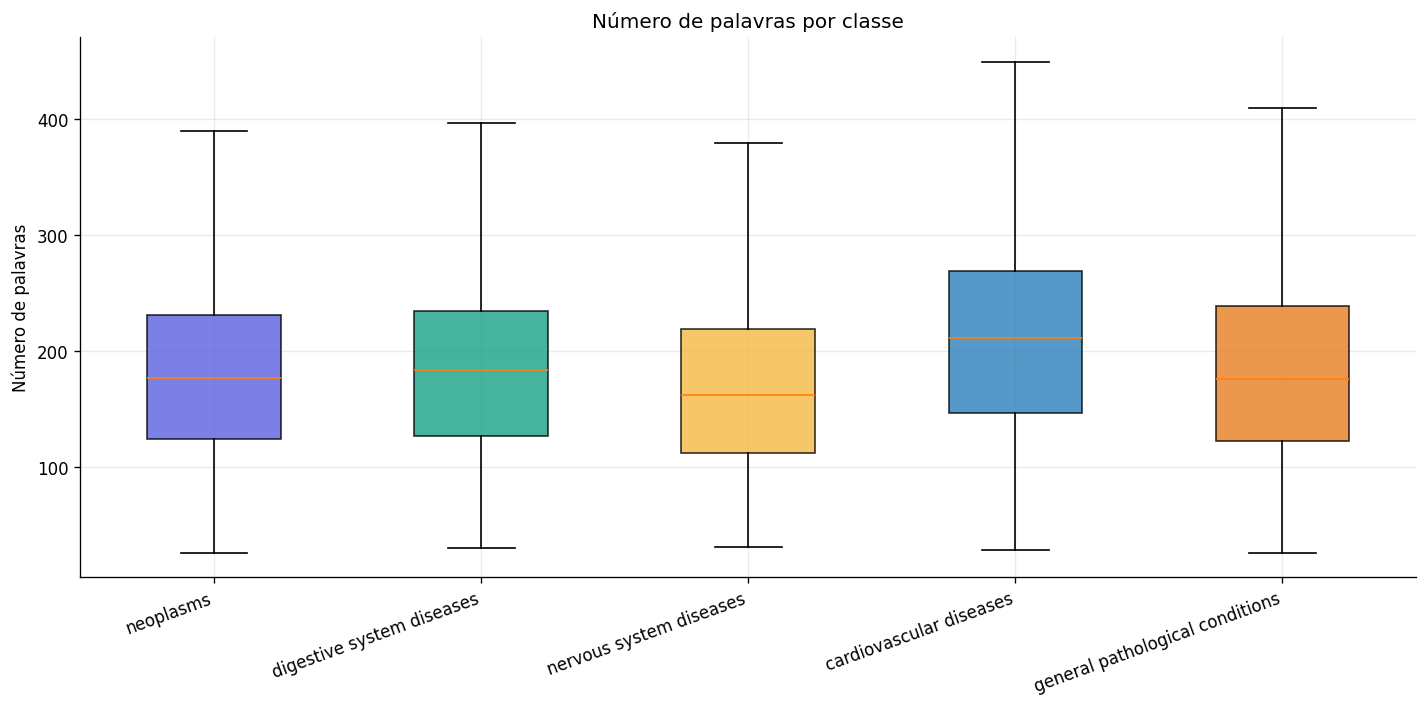

In [13]:
class_order = labels['condition_name'].tolist()
class_word_data = [
    train_eda.loc[train_eda['condition_name'] == class_name, 'n_words']
    for class_name in class_order
]
fig, ax = plt.subplots(figsize=(12, 6))
box = ax.boxplot(
    class_word_data,
    tick_labels=class_order,
    patch_artist=True,
    showfliers=False,
)
for patch, color in zip(box['boxes'], CLASS_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_title('Número de palavras por classe')
ax.set_ylabel('Número de palavras')
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.show()

### Interpretação

Os textos possuem tamanho adequado para uma abordagem inicial com **TF-IDF**. As diferenças entre as classes não parecem exigir um tratamento específico nesta etapa.

## 6. Textos repetidos e possível estrutura multilabel

Aqui verificamos se o mesmo resumo aparece associado a mais de uma classe.

In [14]:
combined = pd.concat([train.assign(split='Treino'), test.assign(split='Teste')], ignore_index=True)
grouped_labels = (
    combined.groupby('medical_abstract')['condition_label']
    .agg(lambda values: sorted(set(values)))
    .reset_index(name='labels')
)
grouped_labels['n_labels'] = grouped_labels['labels'].str.len()
label_multiplicity = (
    grouped_labels['n_labels']
    .value_counts()
    .sort_index()
    .rename_axis('Número de classes')
    .reset_index(name='Quantidade de resumos')
)
display(label_multiplicity)

,Número de classes,Quantidade de resumos
0,1,8298
1,2,2653
2,3,270
3,4,6


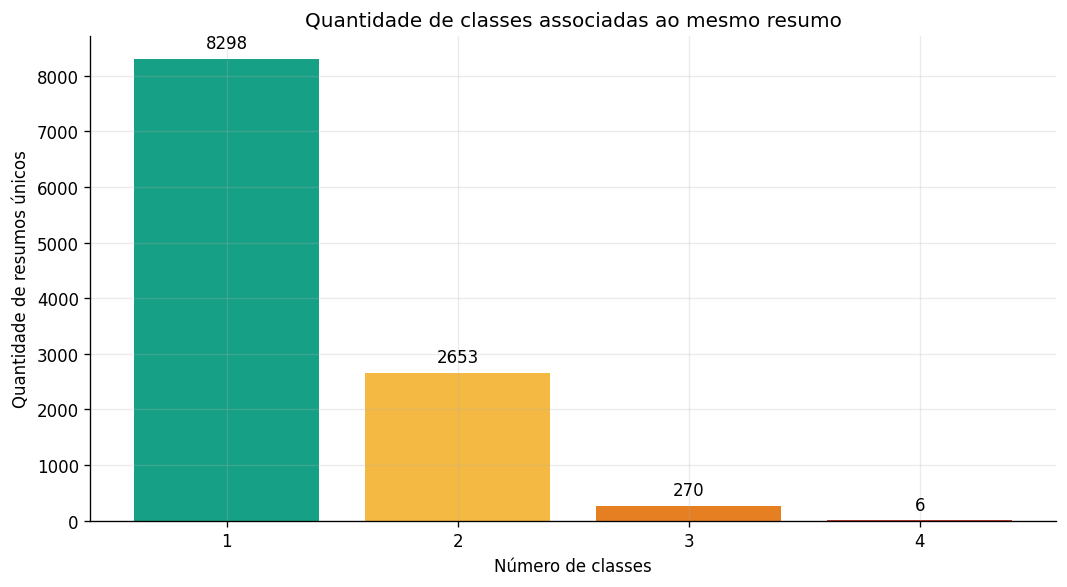

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    label_multiplicity['Número de classes'].astype(str),
    label_multiplicity['Quantidade de resumos'],
    color=['#16A085', '#F4B942', '#E67E22', '#C0392B'][:len(label_multiplicity)],
)
ax.bar_label(bars, padding=4)
ax.set_title('Quantidade de classes associadas ao mesmo resumo')
ax.set_xlabel('Número de classes')
ax.set_ylabel('Quantidade de resumos únicos')
plt.tight_layout()
plt.show()

In [16]:
single_label = int((grouped_labels['n_labels'] == 1).sum())
multi_label = int((grouped_labels['n_labels'] > 1).sum())
total_unique = len(grouped_labels)
print(f'Resumos únicos: {total_unique:,}')
print(f'Com uma classe: {single_label:,} ({single_label/total_unique:.1%})')
print(f'Com mais de uma classe: {multi_label:,} ({multi_label/total_unique:.1%})')

Resumos únicos: 11,227
Com uma classe: 8,298 (73.9%)
Com mais de uma classe: 2,929 (26.1%)


### Interpretação

Uma parte relevante dos resumos está associada a mais de uma categoria. Isso indica características de um problema **multilabel**. Para um primeiro baseline multiclasse, o grupo pode optar por trabalhar apenas com os textos ligados a uma única classe, desde que essa simplificação seja documentada.

## 7. Sobreposição entre treino e teste

Verificamos se o mesmo texto aparece nos dois conjuntos, pois isso pode causar **vazamento de dados**.

In [17]:
train_texts = set(train['medical_abstract'])
test_texts = set(test['medical_abstract'])
overlap = train_texts.intersection(test_texts)
overlap_summary = pd.DataFrame({
    'Grupo': ['Somente treino', 'Treino e teste', 'Somente teste'],
    'Textos únicos': [len(train_texts-test_texts), len(overlap), len(test_texts-train_texts)],
})
display(overlap_summary)

,Grupo,Textos únicos
0,Somente treino,8457
1,Treino e teste,988
2,Somente teste,1782


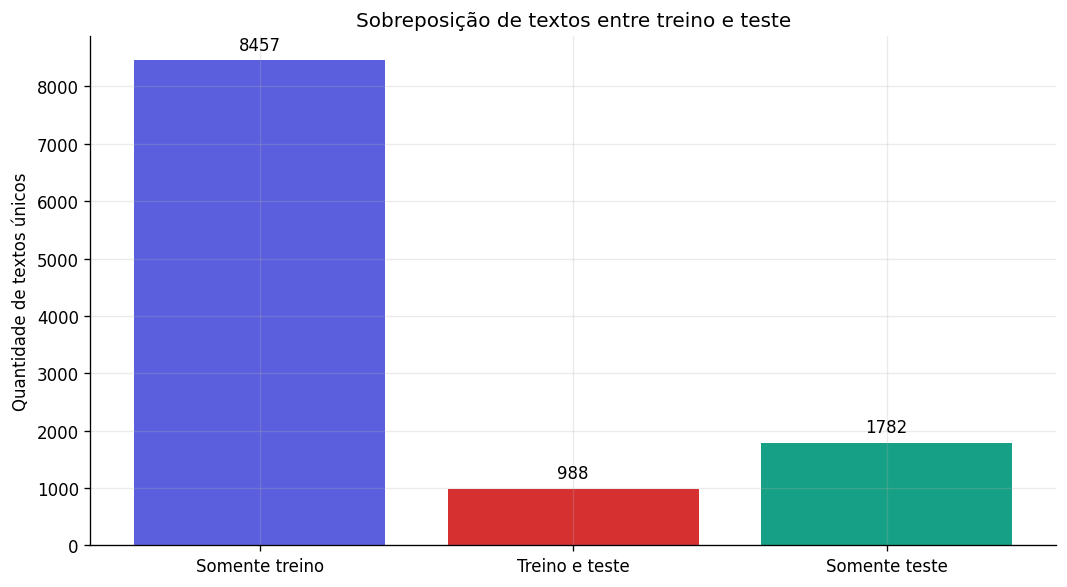

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(overlap_summary['Grupo'], overlap_summary['Textos únicos'], color=['#5B5FDE', '#D63031', '#16A085'])
ax.bar_label(bars, padding=4)
ax.set_title('Sobreposição de textos entre treino e teste')
ax.set_ylabel('Quantidade de textos únicos')
plt.tight_layout()
plt.show()

In [19]:
print(f'Textos idênticos presentes em treino e teste: {len(overlap):,}')

Textos idênticos presentes em treino e teste: 988


### Interpretação

A presença do mesmo resumo em treino e teste pode deixar a avaliação otimista. A recomendação é criar uma nova divisão dos dados **depois de agrupar os registros pelo texto**.

## 8. Palavras mais frequentes

In [20]:
def top_ngrams(texts, ngram_range=(1, 1), top_n=15, min_df=5):
    vectorizer = CountVectorizer(
        lowercase=True,
        stop_words='english',
        ngram_range=ngram_range,
        min_df=min_df,
        token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z\-]{2,}\b',
    )
    matrix = vectorizer.fit_transform(texts.fillna(''))
    frequencies = np.asarray(matrix.sum(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()
    return (
        pd.DataFrame({'termo': terms, 'frequência': frequencies})
        .sort_values('frequência', ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

top_words = top_ngrams(train['medical_abstract'], (1, 1), 15)
display(top_words)

,termo,frequência
0,patients,27408
1,disease,5757
2,group,5029
3,treatment,4840
4,study,4421
5,patient,3809
6,cases,3609
7,blood,3597
8,years,3528
9,clinical,3428


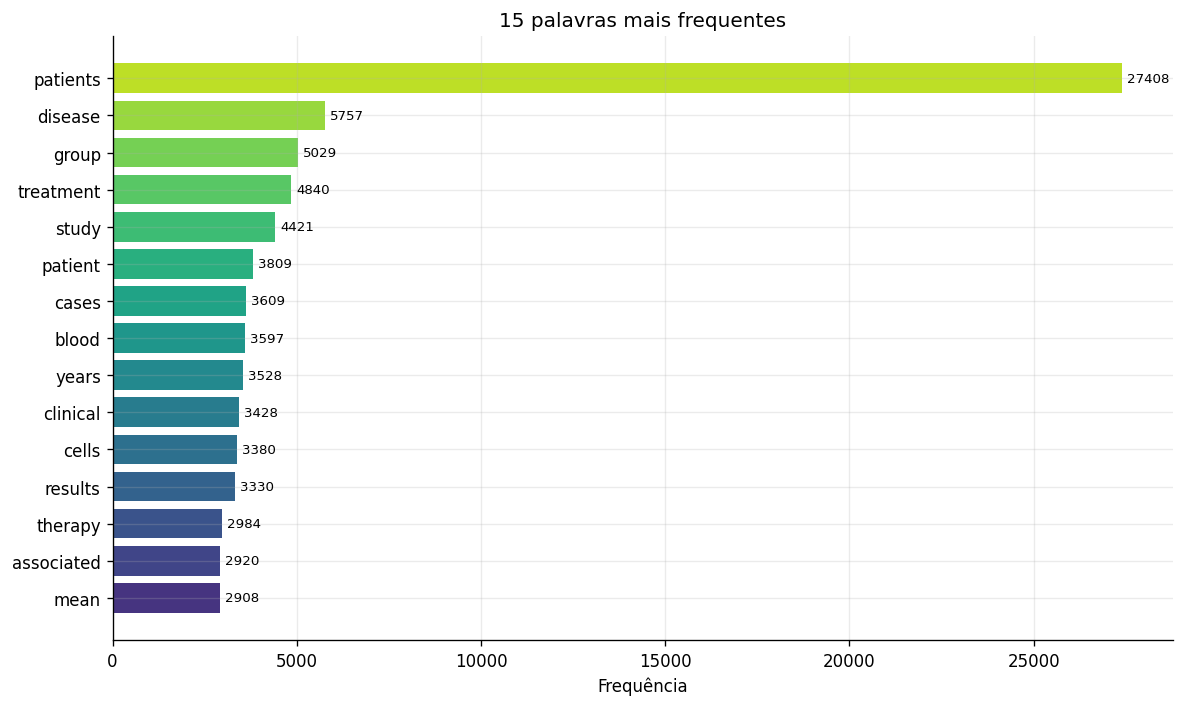

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_data = top_words.sort_values('frequência')
bars = ax.barh(plot_data['termo'], plot_data['frequência'], color=plt.cm.viridis(np.linspace(0.15, 0.9, len(plot_data))))
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_title('15 palavras mais frequentes')
ax.set_xlabel('Frequência')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 9. Bigramas mais frequentes

Bigramas mostram expressões de duas palavras que aparecem juntas com frequência e ajudam a visualizar termos médicos recorrentes.

In [22]:
top_bigrams = top_ngrams(train['medical_abstract'], (2, 2), 15)
display(top_bigrams)

,termo,frequência
0,blood pressure,1146
1,coronary artery,1030
2,left ventricular,953
3,myocardial infarction,772
4,blood flow,591
5,group patients,585
6,magnetic resonance,537
7,risk factors,536
8,patients underwent,527
9,patients treated,486


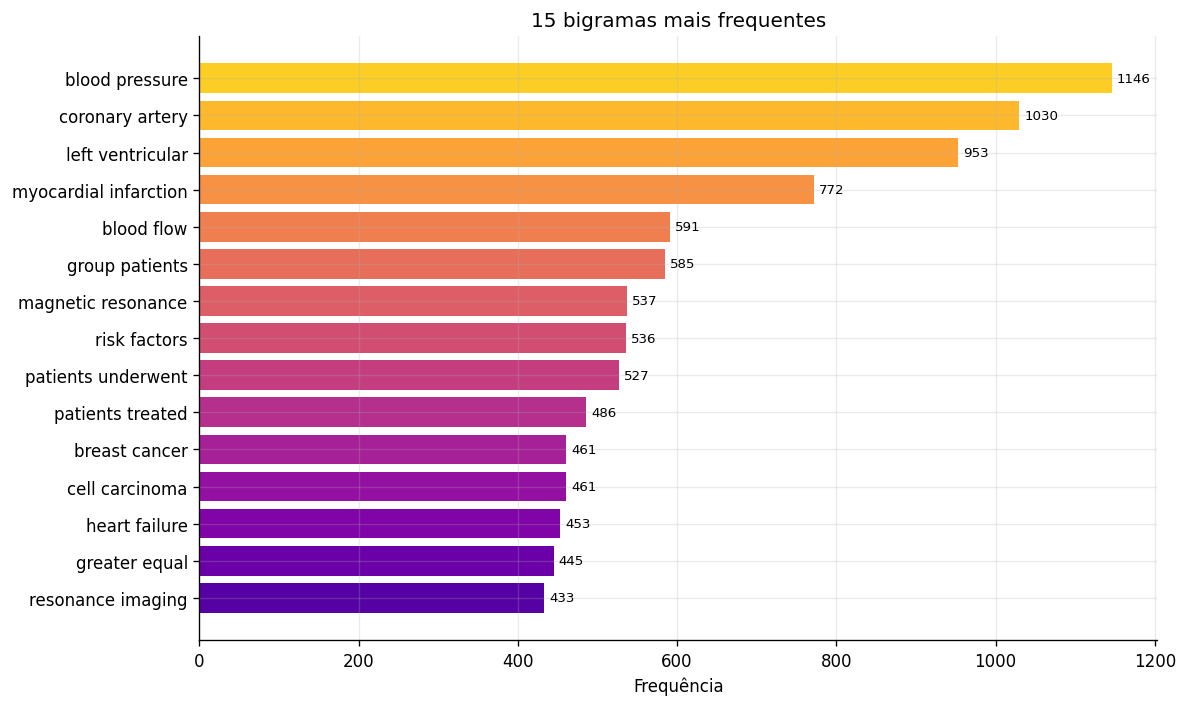

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_data = top_bigrams.sort_values('frequência')
bars = ax.barh(plot_data['termo'], plot_data['frequência'], color=plt.cm.plasma(np.linspace(0.15, 0.9, len(plot_data))))
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_title('15 bigramas mais frequentes')
ax.set_xlabel('Frequência')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 10. Conclusões do EDA

In [24]:
train_counts = train['condition_name'].value_counts()
single_label_count = int((grouped_labels['n_labels'] == 1).sum())
multi_label_count = int((grouped_labels['n_labels'] > 1).sum())

summary_text = f"""### Principais conclusões

- O conjunto possui **{len(train):,} registros de treino** e **{len(test):,} de teste**, distribuídos em **{len(labels)} classes**.
- Não foram encontrados valores ausentes ou textos vazios.
- Existe **desbalanceamento moderado** entre as classes.
- Os resumos possuem mediana de aproximadamente **{train_eda['n_words'].median():.0f} palavras**.
- Existem **{multi_label_count:,} resumos únicos associados a mais de uma classe**.
- Foram encontrados **{len(overlap):,} textos idênticos presentes em treino e teste**, indicando risco de vazamento.
- Para um primeiro baseline multiclasse, uma opção simples é utilizar os **{single_label_count:,} resumos associados a uma única classe** e criar uma nova divisão de treino, validação e teste.
- O target do corpus representa **categorias médicas**, e não níveis de urgência. Essa diferença deve ser documentada no projeto.
"""
display(Markdown(summary_text))

### Principais conclusões

- O conjunto possui **11,550 registros de treino** e **2,888 de teste**, distribuídos em **5 classes**.
- Não foram encontrados valores ausentes ou textos vazios.
- Existe **desbalanceamento moderado** entre as classes.
- Os resumos possuem mediana de aproximadamente **181 palavras**.
- Existem **2,929 resumos únicos associados a mais de uma classe**.
- Foram encontrados **988 textos idênticos presentes em treino e teste**, indicando risco de vazamento.
- Para um primeiro baseline multiclasse, uma opção simples é utilizar os **8,298 resumos associados a uma única classe** e criar uma nova divisão de treino, validação e teste.
- O target do corpus representa **categorias médicas**, e não níveis de urgência. Essa diferença deve ser documentada no projeto.


## Próximo passo

O próximo notebook pode ficar responsável apenas pelo pré-processamento e pela divisão definitiva dos dados:

```text
02_preprocessing_and_split.ipynb
```